#SECTION 1:
##See if I can successfully load ESM-2 and extract embeddings
##Status: Success

In [ ]:
!pip -q install transformers sentencepiece accelerate

In [ ]:
import torch
from transformers import AutoTokenizer, EsmModel

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


In [ ]:
MODEL_NAME = "facebook/esm2_t12_35M_UR50D"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = EsmModel.from_pretrained(MODEL_NAME)
model = model.to(device)
model.eval()

print("Loaded model:", MODEL_NAME)
print("Hidden size:", model.config.hidden_size)
print("Max position embeddings:", model.config.max_position_embeddings)

Loading weights:   0%|          | 0/209 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded model: facebook/esm2_t12_35M_UR50D
Hidden size: 480
Max position embeddings: 1026


In [ ]:
sequence = "MKWVTFISLLFLFSSAYSRGVFRRDAHKSEVAHRFKDLGE"
print("Sequence length:", len(sequence))
print(sequence)

Sequence length: 40
MKWVTFISLLFLFSSAYSRGVFRRDAHKSEVAHRFKDLGE


In [ ]:
inputs = tokenizer(sequence, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

for k, v in inputs.items():
    print(k, v.shape)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print("Tokens:")
print(tokens)
print("Number of tokens including special tokens:", len(tokens))

input_ids torch.Size([1, 42])
attention_mask torch.Size([1, 42])
Tokens:
['<cls>', 'M', 'K', 'W', 'V', 'T', 'F', 'I', 'S', 'L', 'L', 'F', 'L', 'F', 'S', 'S', 'A', 'Y', 'S', 'R', 'G', 'V', 'F', 'R', 'R', 'D', 'A', 'H', 'K', 'S', 'E', 'V', 'A', 'H', 'R', 'F', 'K', 'D', 'L', 'G', 'E', '<eos>']
Number of tokens including special tokens: 42


In [ ]:
with torch.no_grad():
    outputs = model(**inputs)

last_hidden_state = outputs.last_hidden_state
print("last_hidden_state shape:", last_hidden_state.shape)
# shape should be: [batch_size, num_tokens, hidden_size]

last_hidden_state shape: torch.Size([1, 42, 480])


In [ ]:
token_embeddings = last_hidden_state[0]      # [num_tokens, hidden_size]
residue_embeddings = token_embeddings[1:-1]  # drop BOS and EOS

print("Token embedding shape:", token_embeddings.shape)
print("Residue embedding shape:", residue_embeddings.shape)
print("Sequence length:", len(sequence))

assert residue_embeddings.shape[0] == len(sequence), (
    f"Mismatch: got {residue_embeddings.shape[0]} embeddings for "
    f"{len(sequence)} residues"
)

print("Success: one embedding per residue.")

Token embedding shape: torch.Size([42, 480])
Residue embedding shape: torch.Size([40, 480])
Sequence length: 40
Success: one embedding per residue.


In [ ]:
mean_pooled_embedding = residue_embeddings.mean(dim=0)

print("Mean pooled embedding shape:", mean_pooled_embedding.shape)

Mean pooled embedding shape: torch.Size([480])


In [ ]:
print("First residue:", sequence[0])
print("First residue embedding shape:", residue_embeddings[0].shape)
print("First 10 values of first residue embedding:")
print(residue_embeddings[0][:10].detach().cpu())

print("\nFirst 10 values of mean pooled embedding:")
print(mean_pooled_embedding[:10].detach().cpu())

First residue: M
First residue embedding shape: torch.Size([480])
First 10 values of first residue embedding:
tensor([-0.5763,  0.0476, -0.2416,  0.7967,  0.1922,  0.4116, -0.2812, -0.0340,
         0.2014, -0.0168])

First 10 values of mean pooled embedding:
tensor([-0.1130, -0.0505,  0.3344, -0.0534,  0.0949, -0.0536, -0.2463,  0.0981,
         0.1922, -0.0571])


In [ ]:
def extract_esm2_embeddings(sequence, tokenizer, model, device):
    model.eval()

    inputs = tokenizer(sequence, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    token_embeddings = outputs.last_hidden_state[0]   # [num_tokens, hidden_size]
    residue_embeddings = token_embeddings[1:-1]       # remove BOS/EOS

    assert residue_embeddings.shape[0] == len(sequence), (
        f"Expected {len(sequence)} residue embeddings, "
        f"got {residue_embeddings.shape[0]}"
    )

    mean_pooled_embedding = residue_embeddings.mean(dim=0)

    return {
        "residue_embeddings": residue_embeddings.detach().cpu(),
        "mean_pooled_embedding": mean_pooled_embedding.detach().cpu(),
    }

result = extract_esm2_embeddings(sequence, tokenizer, model, device)

print("Residue embeddings:", result["residue_embeddings"].shape)
print("Mean pooled embedding:", result["mean_pooled_embedding"].shape)

Residue embeddings: torch.Size([40, 480])
Mean pooled embedding: torch.Size([480])


#SECTION 2:
#See if I can properly load in secondary structure dataset from ProteinNet
#Status: Complete

In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

ds = load_dataset("proteinea/secondary_structure_prediction")
print(ds)

DatasetDict({
    train: Dataset({
        features: ['input', 'dssp3', 'dssp8', 'disorder', 'cb513_mask'],
        num_rows: 10792
    })
})


In [ ]:
example = ds["train"][0]

seq = example["input"]
ss = example["dssp3"]
dis = example["disorder"]

print(len(seq), len(ss), len(dis))
print(set(ss), set(dis))

330 330 1319
{'E', 'H', 'C'} {' ', '.', '0', '1'}


In [ ]:
mask = example["cb513_mask"]

valid_positions = [m == '1' for m in mask]

print(len(valid_positions))
print(sum(valid_positions))

1319
330


In [ ]:
def process_example(example):
    seq = example["input"]
    ss = example["dssp3"]
    dis = example["disorder"]
    mask = example["cb513_mask"]

    if isinstance(seq, list):
        seq = "".join(seq)

    # mapping for secondary structure
    ss_map = {'H': 0, 'E': 1, 'C': 2}

    cleaned_seq = []
    cleaned_ss = []
    cleaned_dis = []

    seq_idx = 0

    for i in range(len(mask)):
        if mask[i] == '1':
            if seq_idx >= len(seq):
                break

            if dis[i] in ['0', '1']:
                cleaned_seq.append(seq[seq_idx])
                cleaned_ss.append(ss_map[ss[seq_idx]])  # <-- FIX HERE
                cleaned_dis.append(int(dis[i]))

            seq_idx += 1

    if len(cleaned_seq) < 20:
        return None

    return {
        "sequence": "".join(cleaned_seq),
        "ss_labels": cleaned_ss,
        "disorder_labels": cleaned_dis
    }

In [ ]:
#SANTIY CHECK

processed = []

for i in range(10):
    ex = process_example(ds["train"][i])
    if ex is not None:
        processed.append(ex)

for ex in processed:
    print(len(ex["sequence"]), len(ex["ss_labels"]), len(ex["disorder_labels"]))

330 330 330
366 366 366
413 413 413
108 108 108
47 47 47
234 234 234
334 334 334
130 130 130
163 163 163
290 290 290


In [ ]:
processed_data = []

for i in range(3000):
    ex = process_example(ds["train"][i])
    if ex is not None:
        processed_data.append(ex)

print("usable examples:", len(processed_data))

usable examples: 3000


In [ ]:
ex = processed_data[0]
print(ex["sequence"][:50])
print(ex["ss_labels"][:50])
print(ex["disorder_labels"][:50])

MKTAYIAKQRQISFVKSHFSRQLEERLGLIEVQAPILSRVGDGTQDNLSG
[2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
[0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [ ]:
from tqdm import tqdm
import torch

embedded_data = []

for ex in tqdm(processed_data):
    out = extract_esm2_embeddings(ex["sequence"], tokenizer, model, device)

    embedded_data.append({
        "embeddings": out["residue_embeddings"],  # [L, d]
        "ss_labels": torch.tensor(ex["ss_labels"]),
        "disorder_labels": torch.tensor(ex["disorder_labels"])
    })

100%|██████████| 3000/3000 [01:22<00:00, 36.40it/s]


In [ ]:
print(len(embedded_data))

sample = embedded_data[0]
print(sample["embeddings"].shape)
print(sample["ss_labels"].shape)
print(sample["disorder_labels"].shape)

3000
torch.Size([330, 480])
torch.Size([330])
torch.Size([330])


#SECTION 3
#Build dataset for training
#Status: Complete

In [ ]:
#6A helper function
def flatten_task(data, label_key):
    X = []
    y = []

    for item in data:
        X.append(item["embeddings"])
        y.append(item[label_key])

    X = torch.cat(X, dim=0)  # [N, d]
    y = torch.cat(y, dim=0)  # [N]

    return X, y

In [ ]:
#6B split at the protein level
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(
    embedded_data,
    test_size=0.2,
    random_state=42
)

print(len(train_data), len(test_data))

2400 600


In [ ]:
#6C flatten after splitting

# Secondary structure
X_ss_train, y_ss_train = flatten_task(train_data, "ss_labels")
X_ss_test, y_ss_test = flatten_task(test_data, "ss_labels")

# Disorder
X_dis_train, y_dis_train = flatten_task(train_data, "disorder_labels")
X_dis_test, y_dis_test = flatten_task(test_data, "disorder_labels")

print(X_ss_train.shape, X_ss_test.shape)
print(X_dis_train.shape, X_dis_test.shape)

torch.Size([569747, 480]) torch.Size([143510, 480])
torch.Size([569747, 480]) torch.Size([143510, 480])


#SECTION 4
#Train linear probes
#Status: Complete

In [ ]:
#8A Model
import torch.nn as nn

class LinearProbe(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.linear(x)

In [ ]:
#8B Training function
def train_probe(X_train, y_train, X_test, y_test, num_classes, epochs=50, class_weights=None):
    model = LinearProbe(X_train.shape[1], num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    if class_weights is not None:
        loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device))
    else:
        loss_fn = nn.CrossEntropyLoss()

    X_train = X_train.to(device)
    y_train = y_train.to(device)
    X_test = X_test.to(device)
    y_test = y_test.to(device)

    for epoch in range(epochs):
        model.train()

        logits = model(X_train)
        loss = loss_fn(logits, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            preds = model(X_test).argmax(dim=1)
            acc = (preds == y_test).float().mean().item()

        print(f"Epoch {epoch}: loss={loss.item():.4f}, test_acc={acc:.4f}")

    return model

In [ ]:
#8C Train model: Secondary structure, 3 classes
model_ss = train_probe(X_ss_train, y_ss_train, X_ss_test, y_ss_test, num_classes=3)

Epoch 0: loss=1.0918, test_acc=0.4174
Epoch 1: loss=1.0799, test_acc=0.4272
Epoch 2: loss=1.0683, test_acc=0.4373
Epoch 3: loss=1.0571, test_acc=0.4482
Epoch 4: loss=1.0463, test_acc=0.4596
Epoch 5: loss=1.0358, test_acc=0.4723
Epoch 6: loss=1.0256, test_acc=0.4849
Epoch 7: loss=1.0158, test_acc=0.4976
Epoch 8: loss=1.0062, test_acc=0.5100
Epoch 9: loss=0.9969, test_acc=0.5222
Epoch 10: loss=0.9879, test_acc=0.5342
Epoch 11: loss=0.9791, test_acc=0.5465
Epoch 12: loss=0.9706, test_acc=0.5576
Epoch 13: loss=0.9623, test_acc=0.5685
Epoch 14: loss=0.9542, test_acc=0.5788
Epoch 15: loss=0.9463, test_acc=0.5888
Epoch 16: loss=0.9385, test_acc=0.5977
Epoch 17: loss=0.9310, test_acc=0.6061
Epoch 18: loss=0.9236, test_acc=0.6139
Epoch 19: loss=0.9164, test_acc=0.6216
Epoch 20: loss=0.9094, test_acc=0.6286
Epoch 21: loss=0.9025, test_acc=0.6352
Epoch 22: loss=0.8958, test_acc=0.6415
Epoch 23: loss=0.8892, test_acc=0.6468
Epoch 24: loss=0.8828, test_acc=0.6520
Epoch 25: loss=0.8764, test_acc=0.6

In [ ]:
counts = torch.bincount(y_dis_train)
dis_weights = 1.0 / counts.float()
dis_weights = dis_weights / dis_weights.sum()

In [ ]:
#8D Train model: Disorder, 2 classes
model_dis = train_probe(X_dis_train, y_dis_train, X_dis_test, y_dis_test, num_classes=2, class_weights=dis_weights)

Epoch 0: loss=0.7040, test_acc=0.8891
Epoch 1: loss=0.6907, test_acc=0.8856
Epoch 2: loss=0.6781, test_acc=0.8809
Epoch 3: loss=0.6661, test_acc=0.8742
Epoch 4: loss=0.6549, test_acc=0.8648
Epoch 5: loss=0.6443, test_acc=0.8527
Epoch 6: loss=0.6344, test_acc=0.8372
Epoch 7: loss=0.6251, test_acc=0.8190
Epoch 8: loss=0.6163, test_acc=0.8012
Epoch 9: loss=0.6082, test_acc=0.7833
Epoch 10: loss=0.6005, test_acc=0.7667
Epoch 11: loss=0.5933, test_acc=0.7531
Epoch 12: loss=0.5864, test_acc=0.7408
Epoch 13: loss=0.5800, test_acc=0.7315
Epoch 14: loss=0.5739, test_acc=0.7250
Epoch 15: loss=0.5680, test_acc=0.7210
Epoch 16: loss=0.5624, test_acc=0.7187
Epoch 17: loss=0.5571, test_acc=0.7185
Epoch 18: loss=0.5519, test_acc=0.7195
Epoch 19: loss=0.5470, test_acc=0.7225
Epoch 20: loss=0.5421, test_acc=0.7267
Epoch 21: loss=0.5375, test_acc=0.7317
Epoch 22: loss=0.5330, test_acc=0.7373
Epoch 23: loss=0.5286, test_acc=0.7436
Epoch 24: loss=0.5243, test_acc=0.7503
Epoch 25: loss=0.5202, test_acc=0.7

#SECTION 5
#Evaluation metrics
#Status: Complete

In [ ]:
#8E
from sklearn.metrics import f1_score

def evaluate_f1(model, X, y):
    model.eval()
    X = X.to(device)
    y = y.to(device)

    with torch.no_grad():
        preds = model(X).argmax(dim=1).cpu()
        y = y.cpu()

    return f1_score(y, preds, average="macro")

In [ ]:
print("SS F1:", evaluate_f1(model_ss, X_ss_test, y_ss_test))
print("Disorder F1:", evaluate_f1(model_dis, X_dis_test, y_dis_test))

SS F1: 0.7073690969990217
Disorder F1: 0.6374399109174962


#SECTION 6
#Baseline
#Status: Complete

In [ ]:
#9A One-hot encoding

import torch

AA = "ACDEFGHIKLMNPQRSTVWY"
aa_to_idx = {a:i for i,a in enumerate(AA)}

def sequence_to_onehot(seq):
    vecs = []
    for a in seq:
        v = torch.zeros(20)
        if a in aa_to_idx:
            v[aa_to_idx[a]] = 1.0
        vecs.append(v)
    return torch.stack(vecs)

In [ ]:
#9B Build baseline dataset using SAME train-test split as previous

from sklearn.model_selection import train_test_split

train_proc, test_proc = train_test_split(
    processed_data,
    test_size=0.2,
    random_state=42
)

baseline_train = []
baseline_test = []

# train
for ex in train_proc:
    onehot = sequence_to_onehot(ex["sequence"])
    baseline_train.append({
        "features": onehot,
        "ss_labels": ex["ss_labels"],
        "disorder_labels": ex["disorder_labels"]
    })

# test
for ex in test_proc:
    onehot = sequence_to_onehot(ex["sequence"])
    baseline_test.append({
        "features": onehot,
        "ss_labels": ex["ss_labels"],
        "disorder_labels": ex["disorder_labels"]
    })

In [ ]:
#9C flatten baseline

def flatten_baseline(data, label_key):
    X = []
    y = []

    for item in data:
        X.append(item["features"])
        y.append(torch.tensor(item[label_key], dtype=torch.long))

    X = torch.cat(X, dim=0)  # [N, 20]
    y = torch.cat(y, dim=0)  # [N]

    return X, y

In [ ]:
# Secondary structure
X_ss_base_train, y_ss_base_train = flatten_baseline(baseline_train, "ss_labels")
X_ss_base_test, y_ss_base_test = flatten_baseline(baseline_test, "ss_labels")

# Disorder
X_dis_base_train, y_dis_base_train = flatten_baseline(baseline_train, "disorder_labels")
X_dis_base_test, y_dis_base_test = flatten_baseline(baseline_test, "disorder_labels")

print(X_ss_base_train.shape, X_ss_base_test.shape)
print(X_dis_base_train.shape, X_dis_base_test.shape)

torch.Size([569747, 20]) torch.Size([143510, 20])
torch.Size([569747, 20]) torch.Size([143510, 20])


In [ ]:
#9D.i train baseline model for secondary structure

model_ss_base = train_probe(
    X_ss_base_train, y_ss_base_train,
    X_ss_base_test, y_ss_base_test,
    num_classes=3,
    epochs = 200
)

Epoch 0: loss=1.1306, test_acc=0.2743
Epoch 1: loss=1.1299, test_acc=0.2743
Epoch 2: loss=1.1292, test_acc=0.2781
Epoch 3: loss=1.1286, test_acc=0.2781
Epoch 4: loss=1.1279, test_acc=0.2781
Epoch 5: loss=1.1272, test_acc=0.2781
Epoch 6: loss=1.1265, test_acc=0.2781
Epoch 7: loss=1.1259, test_acc=0.2781
Epoch 8: loss=1.1252, test_acc=0.2781
Epoch 9: loss=1.1246, test_acc=0.2781
Epoch 10: loss=1.1239, test_acc=0.2781
Epoch 11: loss=1.1233, test_acc=0.2781
Epoch 12: loss=1.1226, test_acc=0.2781
Epoch 13: loss=1.1220, test_acc=0.2781
Epoch 14: loss=1.1213, test_acc=0.2781
Epoch 15: loss=1.1207, test_acc=0.2781
Epoch 16: loss=1.1200, test_acc=0.2781
Epoch 17: loss=1.1194, test_acc=0.2781
Epoch 18: loss=1.1188, test_acc=0.2781
Epoch 19: loss=1.1182, test_acc=0.2781
Epoch 20: loss=1.1175, test_acc=0.2781
Epoch 21: loss=1.1169, test_acc=0.2781
Epoch 22: loss=1.1163, test_acc=0.2781
Epoch 23: loss=1.1157, test_acc=0.2781
Epoch 24: loss=1.1151, test_acc=0.2933
Epoch 25: loss=1.1145, test_acc=0.2

In [ ]:
#9D.ii train baseline model for disorder

model_dis_base = train_probe(
    X_dis_base_train, y_dis_base_train,
    X_dis_base_test, y_dis_base_test,
    num_classes=2,
    epochs = 200,
    class_weights=dis_weights
)


Epoch 0: loss=0.7023, test_acc=0.5599
Epoch 1: loss=0.7020, test_acc=0.5599
Epoch 2: loss=0.7017, test_acc=0.5599
Epoch 3: loss=0.7015, test_acc=0.5599
Epoch 4: loss=0.7012, test_acc=0.5599
Epoch 5: loss=0.7010, test_acc=0.5599
Epoch 6: loss=0.7007, test_acc=0.5599
Epoch 7: loss=0.7004, test_acc=0.5599
Epoch 8: loss=0.7002, test_acc=0.5599
Epoch 9: loss=0.6999, test_acc=0.5599
Epoch 10: loss=0.6997, test_acc=0.5599
Epoch 11: loss=0.6994, test_acc=0.5599
Epoch 12: loss=0.6992, test_acc=0.5599
Epoch 13: loss=0.6989, test_acc=0.5599
Epoch 14: loss=0.6987, test_acc=0.5599
Epoch 15: loss=0.6985, test_acc=0.5599
Epoch 16: loss=0.6982, test_acc=0.5599
Epoch 17: loss=0.6980, test_acc=0.5599
Epoch 18: loss=0.6978, test_acc=0.5599
Epoch 19: loss=0.6975, test_acc=0.5599
Epoch 20: loss=0.6973, test_acc=0.5599
Epoch 21: loss=0.6971, test_acc=0.5599
Epoch 22: loss=0.6969, test_acc=0.5599
Epoch 23: loss=0.6966, test_acc=0.5599
Epoch 24: loss=0.6964, test_acc=0.5599
Epoch 25: loss=0.6962, test_acc=0.5


Secondary structure — ESM-2 probe — Raw confusion matrix:
Rows = True, Columns = Predicted
Classes: ['H (helix)', 'E (strand)', 'C (coil)']
[[37891   830 12128]
 [ 3256 15846 13204]
 [ 6963  2714 50678]]

Secondary structure — ESM-2 probe — Row-normalised confusion matrix:
[[0.74516706 0.01632284 0.2385101 ]
 [0.10078623 0.49049712 0.40871665]
 [0.11536741 0.04496728 0.83966531]]


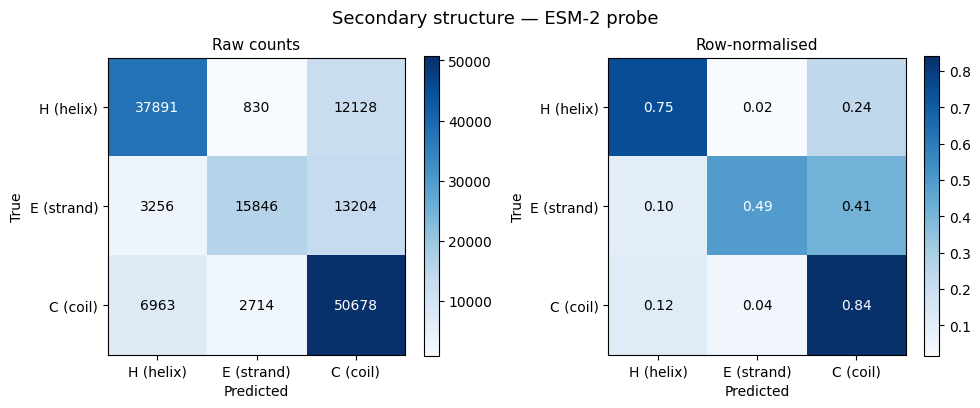


Disorder — ESM-2 probe — Raw confusion matrix:
Rows = True, Columns = Predicted
Classes: ['Ordered', 'Disordered']
[[  6238   1927]
 [ 20065 115280]]

Disorder — ESM-2 probe — Row-normalised confusion matrix:
[[0.76399265 0.23600735]
 [0.14825077 0.85174923]]


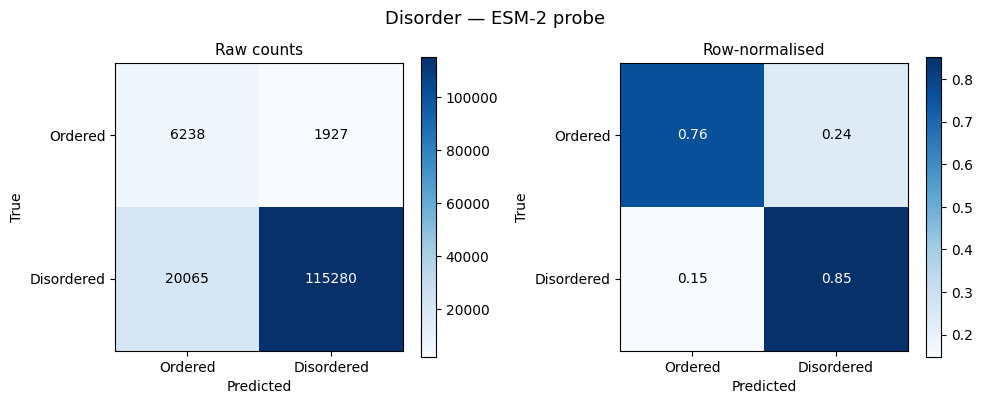

In [ ]:
# Cell 1 — Confusion matrices

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(model, X, y, class_names, title):
    model.eval()
    X = X.to(device)
    with torch.no_grad():
        preds = model(X).argmax(dim=1).cpu().numpy()
    y_np = y.numpy()

    cm = confusion_matrix(y_np, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    #PRINT THE MATRICES
    print(f"\n{title} — Raw confusion matrix:")
    print("Rows = True, Columns = Predicted")
    print("Classes:", class_names)
    print(cm)

    print(f"\n{title} — Row-normalised confusion matrix:")
    print(cm_norm)
    #END PRINT

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(title, fontsize=13)

    for ax, mat, fmt, subtitle in zip(
        axes,
        [cm, cm_norm],
        [".0f", ".2f"],
        ["Raw counts", "Row-normalised"]
    ):
        im = ax.imshow(mat, cmap="Blues")
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names)
        ax.set_yticklabels(class_names)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(subtitle, fontsize=11)
        plt.colorbar(im, ax=ax)

        thresh = mat.max() / 2.0
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                ax.text(j, i, format(mat[i, j], fmt),
                        ha="center", va="center",
                        color="white" if mat[i, j] > thresh else "black",
                        fontsize=10)

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(
    model_ss, X_ss_test, y_ss_test,
    class_names=["H (helix)", "E (strand)", "C (coil)"],
    title="Secondary structure — ESM-2 probe"
)

plot_confusion_matrix(
    model_dis, X_dis_test, y_dis_test,
    class_names=["Ordered", "Disordered"],
    title="Disorder — ESM-2 probe"
)

In [ ]:
# Cell 2 — Per-class F1 breakdown

from sklearn.metrics import f1_score, classification_report
import pandas as pd

def per_class_f1(model, X, y, class_names):
    model.eval()
    X = X.to(device)
    with torch.no_grad():
        preds = model(X).argmax(dim=1).cpu().numpy()
    y_np = y.numpy()

    f1s = f1_score(y_np, preds, average=None)
    macro = f1_score(y_np, preds, average="macro")

    df = pd.DataFrame({
        "Class": class_names,
        "F1": [round(f, 4) for f in f1s]
    })
    df.loc[len(df)] = ["Macro avg", round(macro, 4)]
    return df

ss_names  = ["H (helix)", "E (strand)", "C (coil)"]
dis_names = ["Ordered", "Disordered"]

print("=== Secondary structure ===")
print("ESM-2 probe:")
print(per_class_f1(model_ss, X_ss_test, y_ss_test, ss_names).to_string(index=False))
print("\nBaseline:")
print(per_class_f1(model_ss_base, X_ss_base_test, y_ss_base_test, ss_names).to_string(index=False))

print("\n=== Disorder ===")
print("ESM-2 probe:")
print(per_class_f1(model_dis, X_dis_test, y_dis_test, dis_names).to_string(index=False))
print("\nBaseline:")
print(per_class_f1(model_dis_base, X_dis_base_test, y_dis_base_test, dis_names).to_string(index=False))

=== Secondary structure ===
ESM-2 probe:
     Class     F1
 H (helix) 0.7658
E (strand) 0.6130
  C (coil) 0.7433
 Macro avg 0.7074

Baseline:
     Class     F1
 H (helix) 0.5336
E (strand) 0.0000
  C (coil) 0.5423
 Macro avg 0.3586

=== Disorder ===
ESM-2 probe:
     Class     F1
   Ordered 0.3620
Disordered 0.9129
 Macro avg 0.6374

Baseline:
     Class     F1
   Ordered 0.1386
Disordered 0.7170
 Macro avg 0.4278


In [ ]:
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F

def compute_auc(model, X, y, num_classes):
    model.eval()
    X = X.to(device)
    with torch.no_grad():
        logits = model(X)
        probs = F.softmax(logits, dim=1).cpu().numpy()
    y_np = y.numpy()

    if num_classes == 2:
        auc = roc_auc_score(y_np, probs[:, 1])
    else:
        auc = roc_auc_score(y_np, probs, multi_class="ovr", average="macro")

    return round(auc, 4)

print("=== AUC ===")
print("Secondary structure — ESM-2 probe:", compute_auc(model_ss, X_ss_test, y_ss_test, num_classes=3))
print("Secondary structure — Baseline:   ", compute_auc(model_ss_base, X_ss_base_test, y_ss_base_test, num_classes=3))
print("Disorder — ESM-2 probe:           ", compute_auc(model_dis, X_dis_test, y_dis_test, num_classes=2))
print("Disorder — Baseline:              ", compute_auc(model_dis_base, X_dis_base_test, y_dis_base_test, num_classes=2))

=== AUC ===
Secondary structure — ESM-2 probe: 0.8783
Secondary structure — Baseline:    0.6106
Disorder — ESM-2 probe:            0.8786
Disorder — Baseline:               0.6228


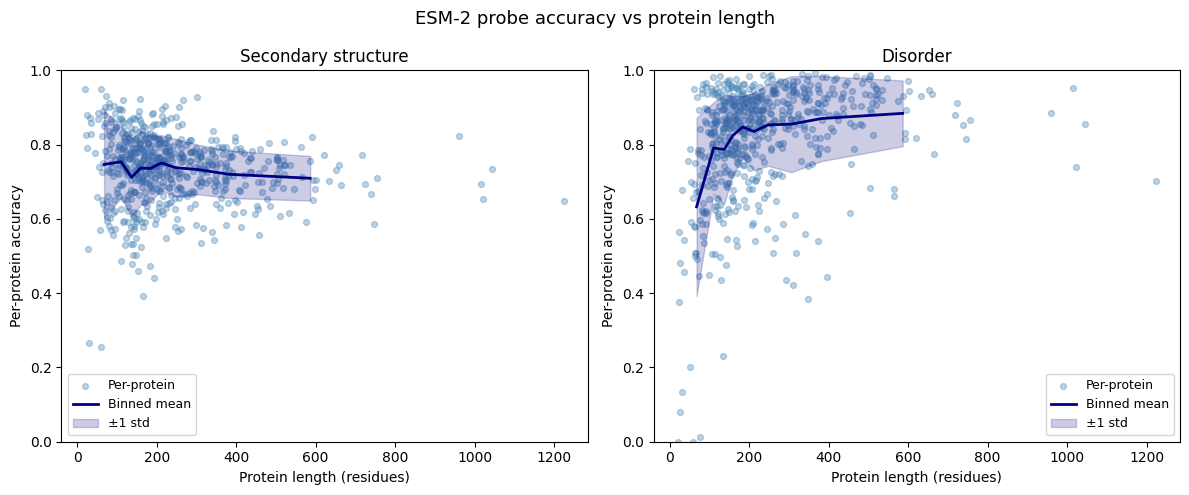

In [ ]:
# Cell 3 — Probe accuracy vs protein length

def per_protein_accuracy(probe_model, data, label_key):
    """Returns (length, accuracy) for each protein in data."""
    probe_model.eval()
    lengths = []
    accs = []

    for item in data:
        X = item["embeddings"].to(device)
        y = item[label_key].to(device)

        with torch.no_grad():
            preds = probe_model(X).argmax(dim=1)

        acc = (preds == y).float().mean().item()
        lengths.append(X.shape[0])
        accs.append(acc)

    return np.array(lengths), np.array(accs)

lengths_ss,  accs_ss  = per_protein_accuracy(model_ss,  test_data, "ss_labels")
lengths_dis, accs_dis = per_protein_accuracy(model_dis, test_data, "disorder_labels")

# bin by length for a trend line
def bin_by_length(lengths, accs, n_bins=10):
    bins = np.percentile(lengths, np.linspace(0, 100, n_bins + 1))
    bin_ids = np.digitize(lengths, bins[1:-1])
    bin_centers, bin_means, bin_stds = [], [], []
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() > 0:
            bin_centers.append(lengths[mask].mean())
            bin_means.append(accs[mask].mean())
            bin_stds.append(accs[mask].std())
    return np.array(bin_centers), np.array(bin_means), np.array(bin_stds)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, lengths, accs, title in zip(
    axes,
    [lengths_ss,  lengths_dis],
    [accs_ss,     accs_dis],
    ["Secondary structure", "Disorder"]
):
    ax.scatter(lengths, accs, alpha=0.35, s=18, color="steelblue", label="Per-protein")

    centers, means, stds = bin_by_length(lengths, accs)
    ax.plot(centers, means, color="navy", linewidth=2, label="Binned mean")
    ax.fill_between(centers, means - stds, means + stds,
                    alpha=0.2, color="navy", label="±1 std")

    ax.set_xlabel("Protein length (residues)")
    ax.set_ylabel("Per-protein accuracy")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)

plt.suptitle("ESM-2 probe accuracy vs protein length", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
#9E Evaluate baseline F1
ss_base_f1 = evaluate_f1(model_ss_base, X_ss_base_test, y_ss_base_test)
dis_base_f1 = evaluate_f1(model_dis_base, X_dis_base_test, y_dis_base_test)

print("SS baseline F1:", ss_base_f1)
print("Disorder baseline F1:", dis_base_f1)

SS baseline F1: 0.358638540742573
Disorder baseline F1: 0.42780097374462733


In [ ]:
ss_probe_f1 = evaluate_f1(model_ss, X_ss_test, y_ss_test)
dis_probe_f1 = evaluate_f1(model_dis, X_dis_test, y_dis_test)

print("SS probe F1:", ss_probe_f1)
print("Disorder probe F1:", dis_probe_f1)

SS probe F1: 0.7073690969990217
Disorder probe F1: 0.6374399109174962


In [ ]:
print("SS improvement:", ss_probe_f1 - ss_base_f1)
print("Disorder improvement:", dis_probe_f1 - dis_base_f1)

SS improvement: 0.3487305562564487
Disorder improvement: 0.20963893717286886
